# 04. Train LightGBM Model

В этом ноутбуке обучаем основную ML-модель для кредитного скоринга — LightGBM.

В отличие от scorecard-модели из ноутбука `03_woe_iv_scorecard.ipynb`, LightGBM умеет хорошо работать с нелинейными зависимостями, пропусками и большим числом признаков.

Основные шаги:

1. Загружаем подготовленные признаки.
2. Разделяем данные на train/validation.
3. Обрабатываем категориальные признаки.
4. Обучаем LightGBM-модель.
5. Оцениваем качество на validation.
6. Сохраняем модель, метрики, feature importance и test predictions.

In [1]:
import json
import pickle
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)

In [3]:
try:
    import lightgbm as lgb
    from lightgbm import LGBMClassifier

    print("LightGBM version:", lgb.__version__)

except ImportError as e:
    print("LightGBM is not installed.")
    print("Install it with: pip install lightgbm")
    raise e

LightGBM version: 4.6.0


In [4]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"

MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("PROCESSED_DIR:", PROCESSED_DIR)
print("MODELS_DIR:", MODELS_DIR)
print("FIGURES_DIR:", FIGURES_DIR)

PROJECT_ROOT: /Users/artem/PycharmProjects/credit-risk-scoring-service
PROCESSED_DIR: /Users/artem/PycharmProjects/credit-risk-scoring-service/data/processed
MODELS_DIR: /Users/artem/PycharmProjects/credit-risk-scoring-service/models
FIGURES_DIR: /Users/artem/PycharmProjects/credit-risk-scoring-service/reports/figures


## 1. Загрузка данных

Используем подготовленные признаки из `data/processed`:

- `train_features.parquet`;
- `test_features.parquet`;
- `feature_columns.csv`.

В train-датасете есть целевая переменная `TARGET`, а в test-датасете её нет.

In [5]:
train_path = PROCESSED_DIR / "train_features.parquet"
test_path = PROCESSED_DIR / "test_features.parquet"
feature_columns_path = PROCESSED_DIR / "feature_columns.csv"

train = pd.read_parquet(train_path)
test = pd.read_parquet(test_path)

if feature_columns_path.exists():
    feature_columns = pd.read_csv(feature_columns_path)
    print("feature_columns:", feature_columns.shape)

print("train:", train.shape)
print("test:", test.shape)

feature_columns: (323, 1)
train: (307511, 324)
test: (48744, 323)


In [6]:
TARGET = "TARGET"
ID_COL = "SK_ID_CURR"

print("TARGET in train:", TARGET in train.columns)
print("ID_COL in train:", ID_COL in train.columns)
print("ID_COL in test:", ID_COL in test.columns)

train.head()

TARGET in train: True
ID_COL in train: True
ID_COL in test: True


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,...,PREV_NAME_CONTRACT_TYPE_Cash loans,PREV_NAME_CONTRACT_TYPE_Consumer loans,PREV_NAME_CONTRACT_TYPE_Revolving loans,PREV_NAME_CONTRACT_TYPE_XNA,PREV_NAME_CONTRACT_TYPE_nan,PREV_NAME_CLIENT_TYPE_New,PREV_NAME_CLIENT_TYPE_Refreshed,PREV_NAME_CLIENT_TYPE_Repeater,PREV_NAME_CLIENT_TYPE_XNA,PREV_NAME_CLIENT_TYPE_nan,PREV_CHANNEL_TYPE_AP+ (Cash loan),PREV_CHANNEL_TYPE_Car dealer,PREV_CHANNEL_TYPE_Channel of corporate sales,PREV_CHANNEL_TYPE_Contact center,PREV_CHANNEL_TYPE_Country-wide,PREV_CHANNEL_TYPE_Credit and cash offices,PREV_CHANNEL_TYPE_Regional / Local,PREV_CHANNEL_TYPE_Stone,PREV_CHANNEL_TYPE_nan,PREV_NAME_YIELD_GROUP_XNA,PREV_NAME_YIELD_GROUP_high,PREV_NAME_YIELD_GROUP_low_action,PREV_NAME_YIELD_GROUP_low_normal,PREV_NAME_YIELD_GROUP_middle,PREV_NAME_YIELD_GROUP_nan,PREV_APPROVED_RATIO,PREV_REFUSED_RATIO,PREV_CANCELED_RATIO,POS_RECORDS_COUNT,POS_PREV_UNIQUE_COUNT,POS_MONTHS_BALANCE_MEAN,POS_MONTHS_BALANCE_MIN,POS_MONTHS_BALANCE_MAX,POS_CNT_INSTALMENT_MEAN,POS_CNT_INSTALMENT_MAX,POS_CNT_INSTALMENT_FUTURE_MEAN,POS_CNT_INSTALMENT_FUTURE_MAX,POS_SK_DPD_MEAN,POS_SK_DPD_MAX,POS_SK_DPD_DEF_MEAN,POS_SK_DPD_DEF_MAX,POS_NAME_CONTRACT_STATUS_Active,POS_NAME_CONTRACT_STATUS_Amortized debt,POS_NAME_CONTRACT_STATUS_Approved,POS_NAME_CONTRACT_STATUS_Canceled,POS_NAME_CONTRACT_STATUS_Completed,POS_NAME_CONTRACT_STATUS_Demand,POS_NAME_CONTRACT_STATUS_Returned to the store,POS_NAME_CONTRACT_STATUS_Signed,POS_NAME_CONTRACT_STATUS_XNA,POS_NAME_CONTRACT_STATUS_nan,INSTAL_RECORDS_COUNT,INSTAL_PREV_UNIQUE_COUNT,INSTAL_NUM_INSTALMENT_VERSION_MEAN,INSTAL_NUM_INSTALMENT_NUMBER_MAX,INSTAL_DAYS_INSTALMENT_MEAN,INSTAL_DAYS_ENTRY_PAYMENT_MEAN,INSTAL_PAYMENT_DELAY_MEAN,INSTAL_PAYMENT_DELAY_MAX,INSTAL_PAYMENT_DELAY_SUM,INSTAL_PAYMENT_DIFF_MEAN,INSTAL_PAYMENT_DIFF_SUM,INSTAL_LATE_PAYMENT_MEAN,INSTAL_LATE_PAYMENT_SUM,INSTAL_UNDERPAYMENT_MEAN,INSTAL_UNDERPAYMENT_SUM,INSTAL_AMT_INSTALMENT_MEAN,INSTAL_AMT_INSTALMENT_SUM,INSTAL_AMT_PAYMENT_MEAN,INSTAL_AMT_PAYMENT_SUM,CC_RECORDS_COUNT,CC_PREV_UNIQUE_COUNT,CC_MONTHS_BALANCE_MEAN,CC_MONTHS_BALANCE_MIN,CC_MONTHS_BALANCE_MAX,CC_AMT_BALANCE_MEAN,CC_AMT_BALANCE_MAX,CC_AMT_CREDIT_LIMIT_ACTUAL_MEAN,CC_AMT_CREDIT_LIMIT_ACTUAL_MAX,CC_AMT_DRAWINGS_CURRENT_MEAN,CC_AMT_DRAWINGS_CU

In [7]:
feature_cols = [
    col for col in train.columns
    if col not in [TARGET, ID_COL]
]

X = train[feature_cols].copy()
y = train[TARGET].copy()

test_ids = test[ID_COL].copy()
X_test = test[feature_cols].copy()

print("Количество признаков:", len(feature_cols))
print("X:", X.shape)
print("y:", y.shape)
print("X_test:", X_test.shape)
print("Target mean:", y.mean())

Количество признаков: 322
X: (307511, 322)
y: (307511,)
X_test: (48744, 322)
Target mean: 0.08072881945686496


In [8]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print("X_test:", X_test.shape)

print("y_train mean:", y_train.mean())
print("y_valid mean:", y_valid.mean())

X_train: (246008, 322)
X_valid: (61503, 322)
X_test: (48744, 322)
y_train mean: 0.08072908198107379
y_valid mean: 0.08072776937710356


## 2. Подготовка признаков для tree-based моделей

Tree-based модели умеют работать с нелинейными зависимостями и обычно не требуют масштабирования признаков.

Для LightGBM:

- числовые признаки оставляем как есть;
- пропуски LightGBM умеет обрабатывать сам;
- категориальные признаки приведём к типу `category`;
- бесконечности заменим на `NaN`.

In [9]:
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_valid = X_valid.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

print("Inf cleaned")

Inf cleaned


In [10]:
numeric_features = X_train.select_dtypes(include=["number", "bool"]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=["number", "bool"]).columns.tolist()

print("Числовых признаков:", len(numeric_features))
print("Категориальных признаков:", len(categorical_features))

print("Примеры категориальных:")
display(categorical_features[:20])

Числовых признаков: 306
Категориальных признаков: 16
Примеры категориальных:


['NAME_CONTRACT_TYPE',
 'CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'NAME_TYPE_SUITE',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'OCCUPATION_TYPE',
 'WEEKDAY_APPR_PROCESS_START',
 'ORGANIZATION_TYPE',
 'FONDKAPREMONT_MODE',
 'HOUSETYPE_MODE',
 'WALLSMATERIAL_MODE',
 'EMERGENCYSTATE_MODE']

In [11]:
for col in categorical_features:
    X_train[col] = X_train[col].astype("category")
    X_valid[col] = X_valid[col].astype("category")
    X_test[col] = X_test[col].astype("category")

print("Categorical features converted to category dtype")

Categorical features converted to category dtype


## 3. Tree-based baselines

Перед обучением LightGBM проверим простые tree-based baseline-модели:

- `DecisionTreeClassifier` — одно дерево решений;
- `HistGradientBoostingClassifier` — sklearn-бустинг деревьев.

Это нужно, чтобы сравнить LightGBM не только со scorecard, но и с более простыми деревьями.

In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [13]:
numeric_transformer = SimpleImputer(strategy="median")

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
    ]
)

sklearn_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop"
)

In [14]:
baseline_results = []


def evaluate_binary_model(model_name, model, X_valid_data, y_valid_data):
    valid_proba = model.predict_proba(X_valid_data)[:, 1]

    roc_auc = roc_auc_score(y_valid_data, valid_proba)
    pr_auc = average_precision_score(y_valid_data, valid_proba)

    baseline_results.append(
        {
            "model": model_name,
            "valid_roc_auc": roc_auc,
            "valid_pr_auc": pr_auc,
        }
    )

    print(model_name)
    print("Valid ROC-AUC:", round(roc_auc, 4))
    print("Valid PR-AUC:", round(pr_auc, 4))

    return valid_proba

In [15]:
decision_tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", sklearn_preprocessor),
        (
            "model",
            DecisionTreeClassifier(
                max_depth=5,
                min_samples_leaf=500,
                class_weight="balanced",
                random_state=42,
            ),
        ),
    ]
)

decision_tree_pipeline.fit(X_train, y_train)

dt_valid_proba = evaluate_binary_model(
    "Decision Tree",
    decision_tree_pipeline,
    X_valid,
    y_valid,
)

Decision Tree
Valid ROC-AUC: 0.7265
Valid PR-AUC: 0.1953


In [16]:
hist_gb_pipeline = Pipeline(
    steps=[
        ("preprocessor", sklearn_preprocessor),
        (
            "model",
            HistGradientBoostingClassifier(
                max_iter=200,
                learning_rate=0.05,
                max_leaf_nodes=31,
                l2_regularization=1.0,
                random_state=42,
            ),
        ),
    ]
)

hist_gb_pipeline.fit(X_train, y_train)

hist_gb_valid_proba = evaluate_binary_model(
    "HistGradientBoosting",
    hist_gb_pipeline,
    X_valid,
    y_valid,
)

HistGradientBoosting
Valid ROC-AUC: 0.7846
Valid PR-AUC: 0.2819


## 4. Обучение LightGBM

LightGBM — это градиентный бустинг над деревьями решений.  
Он хорошо подходит для табличных данных и обычно показывает сильное качество на задачах кредитного скоринга.

В этой версии используем:

- `binary` objective;
- `auc` как основную метрику;
- обработку дисбаланса через `scale_pos_weight`;
- early stopping по validation-выборке.

In [17]:
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

print("Negative count:", negative_count)
print("Positive count:", positive_count)
print("scale_pos_weight:", scale_pos_weight)

Negative count: 226148
Positive count: 19860
scale_pos_weight: 11.38710976837865


In [18]:
lgb_train = lgb.Dataset(
    X_train,
    label=y_train,
    categorical_feature=categorical_features,
    free_raw_data=False
)

lgb_valid = lgb.Dataset(
    X_valid,
    label=y_valid,
    categorical_feature=categorical_features,
    reference=lgb_train,
    free_raw_data=False
)

In [22]:
lgb_params = {
    "objective": "binary",
    "metric": "auc",
    "boosting_type": "gbdt",
    "learning_rate": 0.03,
    "num_leaves": 31,
    "max_depth": -1,
    "min_data_in_leaf": 100,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "lambda_l1": 0.0,
    "lambda_l2": 1.0,
    "scale_pos_weight": scale_pos_weight,
    "verbosity": -1,
    "seed": 42,
}

In [23]:
lgb_model = lgb.train(
    params=lgb_params,
    train_set=lgb_train,
    valid_sets=[lgb_train, lgb_valid],
    valid_names=["train", "valid"],
    num_boost_round=2000,
    callbacks=[
        lgb.early_stopping(stopping_rounds=100, first_metric_only=True),
        lgb.log_evaluation(period=100),
    ],
)

Training until validation scores don't improve for 100 rounds
[100]	train's auc: 0.793922	valid's auc: 0.772306
[200]	train's auc: 0.816315	valid's auc: 0.782204
[300]	train's auc: 0.83202	valid's auc: 0.78561
[400]	train's auc: 0.844948	valid's auc: 0.787133
[500]	train's auc: 0.85608	valid's auc: 0.787868
[600]	train's auc: 0.86614	valid's auc: 0.787913
[700]	train's auc: 0.875582	valid's auc: 0.788278
[800]	train's auc: 0.884077	valid's auc: 0.788296
Early stopping, best iteration is:
[770]	train's auc: 0.881492	valid's auc: 0.788398
Evaluated only: auc


In [24]:
lgb_train_proba = lgb_model.predict(
    X_train,
    num_iteration=lgb_model.best_iteration
)

lgb_valid_proba = lgb_model.predict(
    X_valid,
    num_iteration=lgb_model.best_iteration
)

lgb_train_auc = roc_auc_score(y_train, lgb_train_proba)
lgb_valid_auc = roc_auc_score(y_valid, lgb_valid_proba)

lgb_train_pr_auc = average_precision_score(y_train, lgb_train_proba)
lgb_valid_pr_auc = average_precision_score(y_valid, lgb_valid_proba)

baseline_results.append(
    {
        "model": "LightGBM",
        "valid_roc_auc": lgb_valid_auc,
        "valid_pr_auc": lgb_valid_pr_auc,
    }
)

print("Best iteration:", lgb_model.best_iteration)
print("Train ROC-AUC:", round(lgb_train_auc, 4))
print("Valid ROC-AUC:", round(lgb_valid_auc, 4))
print("Train PR-AUC:", round(lgb_train_pr_auc, 4))
print("Valid PR-AUC:", round(lgb_valid_pr_auc, 4))

Best iteration: 770
Train ROC-AUC: 0.8815
Valid ROC-AUC: 0.7884
Train PR-AUC: 0.4096
Valid PR-AUC: 0.2866


## 5. Сравнение tree-based моделей

Сравним качество baseline-деревьев и LightGBM на validation-выборке.

In [31]:
model_comparison = (
    pd.DataFrame(baseline_results)
    .drop_duplicates(subset=["model"], keep="last")
    .sort_values("valid_roc_auc", ascending=False)
    .reset_index(drop=True)
)

model_comparison

,model,valid_roc_auc,valid_pr_auc
0,LightGBM,0.788398,0.286632
1,HistGradientBoosting,0.784587,0.281898
2,Decision Tree,0.726526,0.195315


In [32]:
scorecard_row = pd.DataFrame(
    [
        {
            "model": "WOE Logistic Regression",
            "valid_roc_auc": 0.7683,
            "valid_pr_auc": 0.2549,
        }
    ]
)

model_comparison_with_scorecard = (
    pd.concat([model_comparison, scorecard_row], ignore_index=True)
    .drop_duplicates(subset=["model"], keep="last")
    .sort_values("valid_roc_auc", ascending=False)
    .reset_index(drop=True)
)

model_comparison_with_scorecard

,model,valid_roc_auc,valid_pr_auc
0,LightGBM,0.788398,0.286632
1,HistGradientBoosting,0.784587,0.281898
2,WOE Logistic Regression,0.768300,0.254900
3,Decision Tree,0.726526,0.195315


In [33]:
model_comparison_path = MODELS_DIR / "tree_model_comparison.csv"

model_comparison_with_scorecard.to_csv(model_comparison_path, index=False)

print("Saved:", model_comparison_path)

Saved: /Users/artem/PycharmProjects/credit-risk-scoring-service/models/tree_model_comparison.csv


## 6. ROC и Precision-Recall для LightGBM

Построим ROC и Precision-Recall кривые для финальной LightGBM-модели.

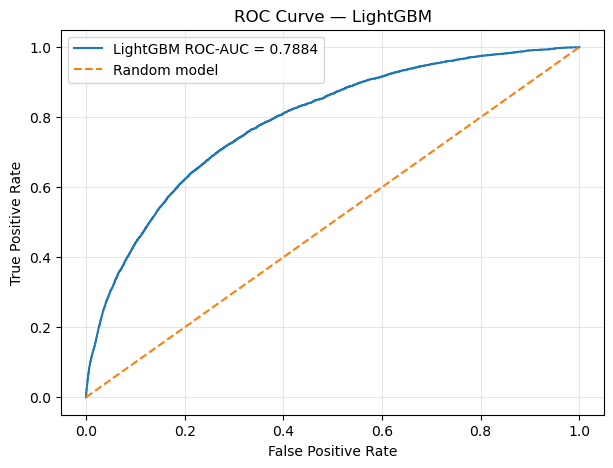

Saved: /Users/artem/PycharmProjects/credit-risk-scoring-service/reports/figures/lightgbm_roc_curve.png


In [34]:
fpr, tpr, roc_thresholds = roc_curve(y_valid, lgb_valid_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"LightGBM ROC-AUC = {lgb_valid_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random model")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — LightGBM")
plt.legend()
plt.grid(alpha=0.3)

lgb_roc_path = FIGURES_DIR / "lightgbm_roc_curve.png"
plt.savefig(lgb_roc_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", lgb_roc_path)

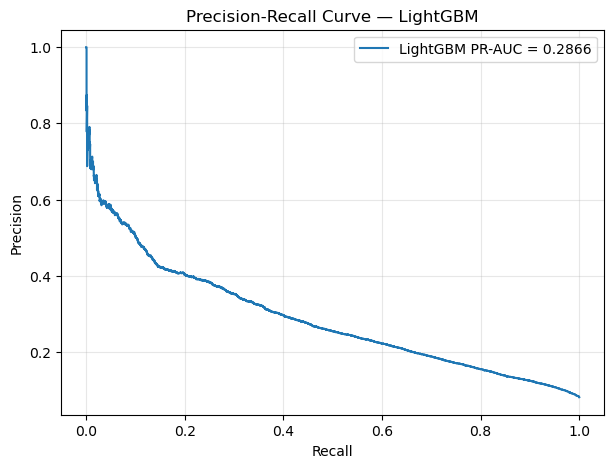

Saved: /Users/artem/PycharmProjects/credit-risk-scoring-service/reports/figures/lightgbm_pr_curve.png


In [35]:
precision, recall, pr_thresholds = precision_recall_curve(
    y_valid,
    lgb_valid_proba
)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, label=f"LightGBM PR-AUC = {lgb_valid_pr_auc:.4f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — LightGBM")
plt.legend()
plt.grid(alpha=0.3)

lgb_pr_path = FIGURES_DIR / "lightgbm_pr_curve.png"
plt.savefig(lgb_pr_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", lgb_pr_path)

## 7. Feature importance

Посмотрим важность признаков LightGBM.

Используем два варианта:

- `split` — сколько раз признак использовался в деревьях;
- `gain` — сколько качества модель получила от разбиений по этому признаку.

Для интерпретации обычно важнее `gain`.

In [36]:
feature_importance = pd.DataFrame({
    "feature": lgb_model.feature_name(),
    "importance_split": lgb_model.feature_importance(importance_type="split"),
    "importance_gain": lgb_model.feature_importance(importance_type="gain"),
})

feature_importance = (
    feature_importance
    .sort_values("importance_gain", ascending=False)
    .reset_index(drop=True)
)

feature_importance.head(30)

,feature,importance_split,importance_gain
0,EXT_SOURCE_MEAN,380,699121.627361
1,ORGANIZATION_TYPE,3251,353852.892649
2,CREDIT_TO_ANNUITY_RATIO,588,83888.123156
3,EXT_SOURCE_MIN,243,64710.610392
4,GOODS_TO_CREDIT_RATIO,229,52596.608986
5,OCCUPATION_TYPE,489,52392.473423
6,INSTAL_LATE_PAYMENT_MEAN,211,51970.770149
7,EXT_SOURCE_MAX,163,46162.143646
8,EXT_SOURCE_3,333,43705.023626
9,EXT_SOURCE_1,322,40709.562662


In [37]:
feature_importance_path = MODELS_DIR / "lightgbm_feature_importance.csv"

feature_importance.to_csv(feature_importance_path, index=False)

print("Saved:", feature_importance_path)

Saved: /Users/artem/PycharmProjects/credit-risk-scoring-service/models/lightgbm_feature_importance.csv


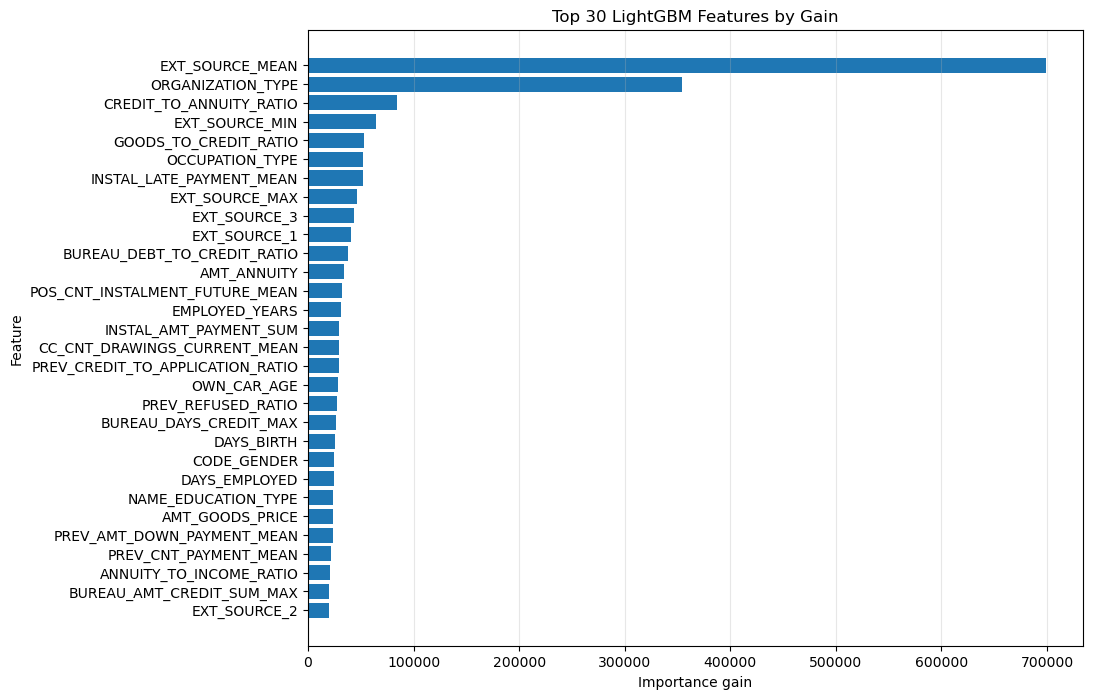

Saved: /Users/artem/PycharmProjects/credit-risk-scoring-service/reports/figures/lightgbm_feature_importance.png


In [38]:
top_n = 30

top_features = feature_importance.head(top_n).sort_values(
    "importance_gain",
    ascending=True
)

plt.figure(figsize=(10, 8))
plt.barh(
    top_features["feature"],
    top_features["importance_gain"]
)

plt.xlabel("Importance gain")
plt.ylabel("Feature")
plt.title(f"Top {top_n} LightGBM Features by Gain")
plt.grid(axis="x", alpha=0.3)

feature_importance_plot_path = FIGURES_DIR / "lightgbm_feature_importance.png"
plt.savefig(feature_importance_plot_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", feature_importance_plot_path)

## 8. Сохранение LightGBM-модели и метрик

Сохраним обученную LightGBM-модель, список признаков, параметры и метрики качества.

Эти артефакты понадобятся для следующих ноутбуков:

- `05_model_evaluation.ipynb`;
- `06_inference_demo.ipynb`;
- API-сервиса.

In [39]:
lightgbm_model_path = MODELS_DIR / "lightgbm_model.pkl"

with open(lightgbm_model_path, "wb") as f:
    pickle.dump(lgb_model, f)

print("Saved:", lightgbm_model_path)

Saved: /Users/artem/PycharmProjects/credit-risk-scoring-service/models/lightgbm_model.pkl


In [40]:
feature_list_path = MODELS_DIR / "lightgbm_feature_list.json"

with open(feature_list_path, "w", encoding="utf-8") as f:
    json.dump(feature_cols, f, ensure_ascii=False, indent=2)

print("Saved:", feature_list_path)

Saved: /Users/artem/PycharmProjects/credit-risk-scoring-service/models/lightgbm_feature_list.json


In [41]:
lightgbm_params_path = MODELS_DIR / "lightgbm_params.json"

params_to_save = {
    **lgb_params,
    "best_iteration": int(lgb_model.best_iteration),
    "categorical_features": categorical_features,
}

with open(lightgbm_params_path, "w", encoding="utf-8") as f:
    json.dump(params_to_save, f, ensure_ascii=False, indent=2)

print("Saved:", lightgbm_params_path)

Saved: /Users/artem/PycharmProjects/credit-risk-scoring-service/models/lightgbm_params.json


In [42]:
lightgbm_metrics = {
    "model": "lightgbm",
    "best_iteration": int(lgb_model.best_iteration),
    "n_features": len(feature_cols),
    "n_categorical_features": len(categorical_features),
    "n_numeric_features": len(numeric_features),
    "train_roc_auc": float(lgb_train_auc),
    "valid_roc_auc": float(lgb_valid_auc),
    "train_pr_auc": float(lgb_train_pr_auc),
    "valid_pr_auc": float(lgb_valid_pr_auc),
}

lightgbm_metrics_path = MODELS_DIR / "lightgbm_metrics.json"

with open(lightgbm_metrics_path, "w", encoding="utf-8") as f:
    json.dump(lightgbm_metrics, f, ensure_ascii=False, indent=2)

lightgbm_metrics

{'model': 'lightgbm',
 'best_iteration': 770,
 'n_features': 322,
 'n_categorical_features': 16,
 'n_numeric_features': 306,
 'train_roc_auc': 0.881491923646647,
 'valid_roc_auc': 0.7883975154960883,
 'train_pr_auc': 0.40962482529541816,
 'valid_pr_auc': 0.2866316232885762}

## 9. Предсказания для test

Применим обученную LightGBM-модель к test-выборке и сохраним:

- полный файл с `SK_ID_CURR` и вероятностью дефолта;
- submission-файл в формате Kaggle.

In [43]:
lgb_test_proba = lgb_model.predict(
    X_test,
    num_iteration=lgb_model.best_iteration
)

lightgbm_test_predictions = pd.DataFrame({
    ID_COL: test_ids.values,
    "TARGET": lgb_test_proba,
})

lightgbm_test_predictions.head()

,SK_ID_CURR,TARGET
0,100001,0.227731
1,100005,0.751526
2,100013,0.194432
3,100028,0.332313
4,100038,0.629138


In [44]:
lightgbm_test_predictions["TARGET"].describe()

count    48744.000000
mean         0.333188
std          0.224605
min          0.003112
25%          0.141531
50%          0.285076
75%          0.498033
max          0.953450
Name: TARGET, dtype: float64

In [45]:
lightgbm_test_predictions_path = MODELS_DIR / "lightgbm_test_predictions.csv"

lightgbm_test_predictions.to_csv(lightgbm_test_predictions_path, index=False)

print("Saved:", lightgbm_test_predictions_path)

Saved: /Users/artem/PycharmProjects/credit-risk-scoring-service/models/lightgbm_test_predictions.csv


In [46]:
lightgbm_submission_path = MODELS_DIR / "lightgbm_submission.csv"

lightgbm_test_predictions.to_csv(lightgbm_submission_path, index=False)

print("Saved:", lightgbm_submission_path)

lightgbm_test_predictions.head()

Saved: /Users/artem/PycharmProjects/credit-risk-scoring-service/models/lightgbm_submission.csv


,SK_ID_CURR,TARGET
0,100001,0.227731
1,100005,0.751526
2,100013,0.194432
3,100028,0.332313
4,100038,0.629138


## 10. Выводы

В этом ноутбуке была обучена основная tree-based модель — LightGBM.

Что было сделано:

1. Загружены подготовленные признаки из `data/processed`.
2. Данные разделены на train и validation с сохранением доли дефолтов.
3. Проверены baseline-модели на деревьях:
   - Decision Tree;
   - HistGradientBoosting.
4. Обучена LightGBM-модель с early stopping.
5. LightGBM показал лучшее качество среди протестированных моделей:
   - ROC-AUC около `0.788`;
   - PR-AUC около `0.287`.
6. Построены ROC и Precision-Recall кривые.
7. Посчитана feature importance.
8. Сохранены модель, параметры, метрики, feature importance и test predictions.

LightGBM стал основной ML-моделью проекта.  
В следующем ноутбуке `05_model_evaluation.ipynb` нужно сравнить scorecard и LightGBM более подробно, проверить threshold policy, calibration и подготовить финальный model report.

In [47]:
saved_files = [
    MODELS_DIR / "tree_model_comparison.csv",
    MODELS_DIR / "lightgbm_feature_importance.csv",
    MODELS_DIR / "lightgbm_model.pkl",
    MODELS_DIR / "lightgbm_feature_list.json",
    MODELS_DIR / "lightgbm_params.json",
    MODELS_DIR / "lightgbm_metrics.json",
    MODELS_DIR / "lightgbm_test_predictions.csv",
    MODELS_DIR / "lightgbm_submission.csv",
    FIGURES_DIR / "lightgbm_roc_curve.png",
    FIGURES_DIR / "lightgbm_pr_curve.png",
    FIGURES_DIR / "lightgbm_feature_importance.png",
]

for path in saved_files:
    print(path, "->", path.exists())

/Users/artem/PycharmProjects/credit-risk-scoring-service/models/tree_model_comparison.csv -> True
/Users/artem/PycharmProjects/credit-risk-scoring-service/models/lightgbm_feature_importance.csv -> True
/Users/artem/PycharmProjects/credit-risk-scoring-service/models/lightgbm_model.pkl -> True
/Users/artem/PycharmProjects/credit-risk-scoring-service/models/lightgbm_feature_list.json -> True
/Users/artem/PycharmProjects/credit-risk-scoring-service/models/lightgbm_params.json -> True
/Users/artem/PycharmProjects/credit-risk-scoring-service/models/lightgbm_metrics.json -> True
/Users/artem/PycharmProjects/credit-risk-scoring-service/models/lightgbm_test_predictions.csv -> True
/Users/artem/PycharmProjects/credit-risk-scoring-service/models/lightgbm_submission.csv -> True
/Users/artem/PycharmProjects/credit-risk-scoring-service/reports/figures/lightgbm_roc_curve.png -> True
/Users/artem/PycharmProjects/credit-risk-scoring-service/reports/figures/lightgbm_pr_curve.png -> True
/Users/artem/Pyc